In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import datetime as dt
from arch import arch_model
from keras.models import load_model

In [2]:
from random import randint
from glob import  glob
from cvxopt import matrix
from cvxopt import solvers
from tabulate import tabulate
from datetime import datetime
import itertools

In [3]:
import matplotlib.pyplot as plt

In [4]:
class infoTest:
    def __init__(self):
        pass
    def calculateSharpe(self,npArray):
        sr = npArray.mean()/npArray.std() * np.sqrt(252)
        return sr
    def max_drawdown(self,booksize,returnSeries):
        mdd = 0
        X = returnSeries+booksize
        peak = X[0]
        for x in X:
            if x > peak:
                peak = x
            dd = (peak - x) / booksize
            if dd > mdd:
                mdd = dd
        return mdd
        # rets is array of returns
    def randomAllocateWeigh(self,rets):
        remaining = 1
        weigh = []
        for i in range(len(rets)):
            tempWeigh = round(random(),2)
            weigh.append(tempWeigh)
            remaining = remaining-tempWeigh
        weigh = np.asarray(weigh) / np.sum(weigh)
        # print(np.sum(weigh))
        portfolio = []
        for i in range(len(rets)):
            if len(portfolio) ==0:
                portfolio = rets[i] * weigh[i]
            else:
                portfolio += rets[i] * weigh[i]
        # portfolio = np.asarray(portfolio)/np.sum(weigh)
        return weigh,portfolio
    def randomAllocateListReturns(self,df):
        remaining = 1
        weigh = []
        counter =0
        ret = []
        portfolio = []
        for (columnName, columnData) in df.iteritems():
            tempWeigh = round(random(), 2)
            weigh.append(tempWeigh)
        weigh = np.asarray(weigh) / np.sum(weigh)
        # print(np.sum(weigh))
        
        
        portfolio = []
        counter = 0
        for (columnName, columnData) in df.iteritems():
            if len(portfolio) == 0:
                portfolio = columnData * weigh[counter]
            else:
                portfolio += columnData * weigh[counter]
            counter+=1
        # portfolio = np.asarray(portfolio)/np.sum(weigh)
        return weigh, portfolio
    
    
    def allocateForMaxSharpe(self,df,itertimes):
        maxSharpe = 0
        maxWeigh = []
        finalPnl = []
        for i in range(itertimes):
            weigh, mergePnl = self.randomAllocateListReturns(df)
            tempSharpe = self.calculateSharpe(mergePnl)
            if tempSharpe >= maxSharpe:
                maxSharpe = tempSharpe
                maxWeigh = weigh
                finalPnl = mergePnl
        # maxWeigh = np.asarray(maxWeigh) / np.sum(maxWeigh)
        return maxSharpe, maxWeigh,finalPnl
    
    
    def allocateForMinDD(self,df,itertimes,booksize):
        minDD = 1;
        minDDWeigh = []
        finalPnl = []
        for i in range(itertimes):
            weigh, mergePnl = self.randomAllocateListReturns(df)
            tempDD = self.max_drawdown(booksize,mergePnl)
            if tempDD < minDD:
                minDD = tempDD
                minDDWeigh = weigh
                finalPnl = mergePnl
        return minDD, minDDWeigh,finalPnl

In [5]:
stocks = ['China','Hongkong','Indonesia','Japan','Korea','Singapore']
full_data_dict = {}

for stock in stocks:
    full_data_dict[stock] = pd.read_csv(f'/Users/khai/Desktop/Thesis_Asia_v2/DataSet/{stock}.csv',parse_dates=['Date'],
                                        index_col=['Date'])

In [6]:
train_var_pred = {}
test_var_pred = {}
for stock in stocks:
    train_var_pred[stock] = pd.read_csv(f'/Users/khai/Desktop/Thesis_Asia_v2/CodingFiles/VaR_Prediction_{stock}_train.csv',parse_dates=['Date'],
                                        index_col=['Date'])
    
    test_var_pred[stock] = pd.read_csv(f'/Users/khai/Desktop/Thesis_Asia_v2/CodingFiles/VaR_Prediction_{stock}_test.csv',parse_dates=['Date'],
                                        index_col=['Date'])
    

    
collist = ['Var95_ANN_GARCH_CLAYTON','Var99_ANN_GARCH_CLAYTON','Var95_ANN_GARCH_FRANK','Var99_ANN_GARCH_FRANK',
          'Var95_ANN_GARCH_GUMBEL','Var99_ANN_GARCH_GUMBEL','Var95_ANN_GARCH_GAUSS','Var99_ANN_GARCH_GAUSS',
          'Var95_GARCH_CLAYTON','Var99_GARCH_CLAYTON','Var95_GARCH_FRANK','Var99_GARCH_FRANK','Var95_GARCH_GUMBEL',
          'Var99_GARCH_GUMBEL','Var95_GARCH_GAUSS','Var99_GARCH_GAUSS','Close',
          'Var95_ANN_GNG_CLAYTON','Var99_ANN_GNG_CLAYTON','Var95_ANN_GNG_FRANK','Var99_ANN_GNG_FRANK',
          'Var95_ANN_GNG_GUMBEL','Var99_ANN_GNG_GUMBEL','Var95_ANN_GNG_GAUSS','Var99_ANN_GNG_GAUSS',
          'Var95_GARCH_GNG_CLAYTON','Var99_GARCH_GNG_CLAYTON','Var95_GARCH_GNG_FRANK','Var99_GARCH_GNG_FRANK',
          'Var95_GARCH_GNG_GUMBEL','Var99_GARCH_GNG_GUMBEL','Var95_GARCH_GNG_GAUSS','Var99_GARCH_GNG_GAUSS']  

target_col = ['Close','Var95_ANN_GARCH_CLAYTON','Var95_GARCH_CLAYTON','Var95_GARCH_GNG_CLAYTON']

In [7]:
Var_95_train_pred = {}
Var_95_test_pred = {}

for stock in stocks:
    Var_95_train_pred[stock] = train_var_pred[stock][target_col]
    Var_95_test_pred[stock] = test_var_pred[stock][target_col]

In [8]:
Var_95_train_pred[stock].head()

,Close,Var95_ANN_GARCH_CLAYTON,Var95_GARCH_CLAYTON,Var95_GARCH_GNG_CLAYTON
Date,,,,
2011-02-02,0.008283,-0.011869,-0.013907,-0.015974
2011-02-07,-0.005898,-0.033707,-0.014481,-0.016632
2011-02-08,-0.002136,-0.020943,-0.014559,-0.016722
2011-02-09,-0.010925,-0.024923,-0.013851,-0.015910
2011-02-10,-0.016432,-0.029586,-0.015114,-0.017357


In [9]:
def preprocess_data(stock):
    start = dt.datetime(2011,2,1)
    end = dt.datetime(2021,12,31)
    split_date = dt.datetime(2020,12,31)
    
    ctg = full_data_dict[stock]
    df = np.log(ctg[['Close']]).diff().dropna()*100
    df['std'] = df['Close'].rolling(window=2, center=False).std()
    df['std'] = df['std']/np.sqrt(2)
    df = df.dropna()
    df['target_vol'] = df['std'].shift(-1)
    df = df.dropna()
    
    df['ret_previous'] = df['Close'].shift(1)
    #df['square_log_previous'] = np.log(df['ret_previous']+1)**2
    df['std_previous'] = df['std'].shift(1)
    df = df.dropna()
    
    #### Fit the garch model #####
    
    df_train = df['2011-02-01':'2020-12-31']
    df_test = df['2021-01-01':]
    ret = df['Close']
    am = arch_model(ret,mean='AR',vol='Garch', p=1, o=0, q=1, dist='Normal')
    res = am.fit(last_obs=split_date,disp='off')
    
    #### Use garch model to predict mean,vol ####
    forecasts_train = res.forecast(horizon=1, start=start)
    variance_pred = np.sqrt(forecasts_train.variance[start:].shift(1).dropna())
    mean_pred = forecasts_train.mean[start:]
    
    df_train['forecast_vol_garch'] = variance_pred[start:split_date]
    df_train['garch_mean'] = mean_pred[start:split_date]

    df_test['forecast_vol_garch'] = variance_pred[split_date:]
    df_test['garch_mean'] = mean_pred[split_date:]
    
    df_train = df_train.dropna()
    X_train = df_train[['ret_previous','std_previous','forecast_vol_garch']].values
    y_train = df_train[['target_vol']].values

    X_test = df_test[['ret_previous','std_previous','forecast_vol_garch']].values
    y_test = df_test[['target_vol']].values
    
    return df_train,df_test
    

In [ ]:
train_dict = {}
test_dict = {}
for stock in stocks:
    train_dict[stock],test_dict[stock] = preprocess_data(stock)

In [11]:
df_new = train_dict['China'][['Close']]
df_new_test = test_dict['China'][['Close']]

for stock in stocks[1:]:
    df_append_train = train_dict[stock][['Close']]
    df_new = pd.concat([df_new,df_append_train],axis=1)
    
    df_append_test = test_dict[stock][['Close']]
    df_new_test = pd.concat([df_new_test,df_append_test],axis=1)

df_new.columns = stocks
df_new_test.columns = stocks

In [12]:
port_ret_train = df_new.fillna(0)
port_ret_test = df_new_test.fillna(0)

In [17]:
port_ret_full = pd.concat([port_ret_train,port_ret_test],axis=0)
port_ret_full.to_csv('full_return_data.csv')

EXPORT VOL MEAN FILE

CALCULATING MONTHLY VAR PREDICTION

In [14]:
def calculate_monthly_mean_var(df):
    df_copy = df.copy()
    df_copy = df_copy.reset_index()
    df_copy['month'] = pd.to_datetime(df_copy.Date).dt.month
    df_copy['year'] = pd.to_datetime(df_copy.Date).dt.year
    df_final = df_copy.groupby(['year','month'],as_index=False).mean()
    return df_final

In [15]:
VAR_mean_train = {}
VAR_mean_test = {}

for stock in stocks:
    VAR_mean_train[stock] = calculate_monthly_mean_var(Var_95_train_pred[stock])
    VAR_mean_test[stock] = calculate_monthly_mean_var(Var_95_test_pred[stock])



In [119]:
df_var_ann = Var_95_train_pred['China']['Var95_ANN_GARCH_CLAYTON']

for stock in stocks[1:]:
    df_var_now = Var_95_train_pred[stock]['Var95_ANN_GARCH_CLAYTON']
    df_var_ann = pd.concat([df_var_ann,df_var_now],axis=1)

In [120]:
df_var_garch = Var_95_train_pred['China']['Var95_GARCH_CLAYTON']

for stock in stocks[1:]:
    df_var_now = Var_95_train_pred[stock]['Var95_GARCH_CLAYTON']
    df_var_garch = pd.concat([df_var_garch,df_var_now],axis=1)

In [121]:
df_var_garch.columns = stocks
df_var_garch = df_var_garch.fillna(0)
df_var_garch

,China,Hongkong,Indonesia,Japan,Korea,Singapore
Date,,,,,,
2011-02-02,0.000000,-0.016061,-0.032203,-0.021765,0.000000,-0.013902
2011-02-03,0.000000,0.000000,0.000000,-0.024262,0.000000,0.000000
2011-02-04,0.000000,0.000000,-0.031386,-0.022715,0.000000,0.000000
2011-02-07,0.000000,-0.017523,-0.029271,-0.023069,-0.016629,-0.014476
2011-02-08,0.000000,-0.018568,-0.027222,-0.021764,-0.016274,-0.014554
...,...,...,...,...,...,...
2020-12-25,-0.018415,0.000000,0.000000,-0.015241,0.000000,0.000000
2020-12-28,-0.018895,-0.018042,-0.022228,-0.014373,-0.020854,-0.012963
2020-12-29,-0.017819,-0.017625,-0.023255,-0.014974,-0.019457,-0.012395


In [17]:
df_var_ann.columns = stocks
df_var_ann = df_var_ann.fillna(0)
df_var_ann

,China,Hongkong,Indonesia,Japan,Korea,Singapore
Date,,,,,,
2011-02-02,0.000000,-0.021301,-0.018860,-0.017155,0.000000,-0.007918
2011-02-03,0.000000,0.000000,0.000000,-0.013573,0.000000,0.000000
2011-02-04,0.000000,0.000000,-0.009769,-0.005569,0.000000,0.000000
2011-02-07,0.000000,-0.020134,-0.013184,-0.016017,-0.016655,-0.022601
2011-02-08,0.000000,-0.017500,-0.022756,-0.013678,-0.017660,-0.014019
...,...,...,...,...,...,...
2020-12-25,-0.012583,0.000000,0.000000,-0.006892,0.000000,0.000000
2020-12-28,-0.011859,-0.015195,-0.011147,-0.012809,-0.013818,-0.012642
2020-12-29,-0.012877,-0.013688,-0.013367,-0.014793,-0.009622,-0.000966


In [ ]:
def cum_ret1(df,weight):
    ret = np.dot(df,weight)
    sharpe = it.calculateSharpe(ret)
    return print('sharpe: ', sharpe)

In [160]:
def trad_sharpe(dataframe,rf,dataframe_test,var_mod,start_train,end_train,start_test,end_test):
    it=infoTest()
    
    train_dt = dataframe[start_train:end_train]
    test_dt = dataframe_test[start_test:end_test]
    
    train_var = var_mod[start_train:end_train]
    #test_dt = dataframe[start_test:end_test]
    
    cov = (train_dt.cov()).to_numpy()
    meanvec = (train_dt.mean()).to_numpy()
    meanvec = [i - rf for i in meanvec]
    meanvar = -(train_var.mean()).to_numpy()
    
    thres=np.round(-train_var[start_train:end_train].mean().to_numpy().mean(),3)*0.9
    
    P = matrix(cov, tc='d')
    q = matrix(np.zeros(len(meanvec)), (len(meanvec), 1), tc='d')
    G=[]
    
    for i in range(len(meanvec)):
        k=[0 for x in range(len(meanvec)-1)]
        k.insert(i, -1)
        G.append(k)
        
    G.append(list(meanvar-thres))
    G=matrix(np.array(G))
    H = np.zeros(len(meanvec)+1)
    #H = np.append(H,0.0155)
    h = matrix(H, tc='d')
    A = (matrix(meanvec)).trans()
    b = matrix([1], (1, 1), tc='d')
    sol = ((solvers.qp(P, q, G, h, A, b))['x'])
    solution = [x for x in sol]
    sum = 0
    for i in range(len(solution)):
        sum += solution[i]
    optimizedWeigh = [x / sum for x in solution]
    
    merge = []
    counter = 0
    for (columnName, columnData) in test_dt.iteritems():
        # print(real[counter])
        if len(merge) == 0:
            merge = test_dt[columnName] * optimizedWeigh[counter]
        else:
            merge = merge + test_dt[columnName] * optimizedWeigh[counter]
        counter += 1
    #print(merge)
    print('dd,', it.max_drawdown(booksize=10e3, returnSeries=merge))
    print('sharpe,', it.calculateSharpe(merge))
    merge = merge*10
    # print('value',merge)
    #merge.to_csv(r'/home/hoainam/PycharmProjects/multi_strategy/v_multi/f1m.csv')
    # print(np.cumsum(merge))
    plt.plot(np.cumsum(merge))
    plt.grid(True)
    plt.legend(('old', 'maxsharpe', 'minDD'))
    plt.show()
    return optimizedWeigh
    
    
#     print(cum_ret1(train_dt,optimizedWeigh))
#     print(cum_ret1(test_dt,optimizedWeigh))
#     return optimizedWeigh

     pcost       dcost       gap    pres   dres
 0:  4.2963e+02 -6.3983e+05  7e+05  2e+01  2e+03
 1:  4.6082e+02 -5.4225e+05  6e+05  2e+01  2e+03
 2:  4.2597e+02 -4.5892e+05  6e+05  2e+01  2e+03
 3:  4.4776e+02 -1.8856e+05  2e+05  5e+00  6e+02
 4:  4.3051e+02 -3.3579e+04  5e+04  1e+00  1e+02
 5:  4.7574e+02 -2.0176e+03  2e+03  1e-02  1e+00
 6:  4.3802e+02  2.7190e+02  2e+02  5e-04  6e-02
 7:  3.9588e+02  3.7560e+02  2e+01  5e-13  2e-16
 8:  3.9118e+02  3.8430e+02  7e+00  2e-13  9e-17
 9:  3.8736e+02  3.8651e+02  8e-01  2e-13  9e-17
10:  3.8704e+02  3.8703e+02  9e-03  5e-13  1e-16
11:  3.8703e+02  3.8703e+02  9e-05  5e-13  8e-17
Optimal solution found.
dd, 5.798566051089438e-06
sharpe, 2.2005764687324003


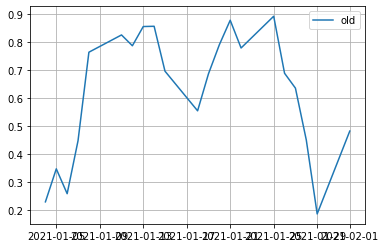

[2.657684425482043e-08,
 2.3416899010859096e-08,
 0.3461886154393867,
 0.015209694889832811,
 0.6386016079575557,
 3.1719481507250874e-08]

In [148]:
#trad_sharpe(dataframe,rf,upperbound,var_mod,start_train,end_train,start_test,end_test)
trad_sharpe(port_ret_train, 0,port_ret_test,df_var_ann,'2016-01-01','2020-12-31','2021-01-01','2021-02-01')

     pcost       dcost       gap    pres   dres
 0:  4.2963e+02 -6.3789e+05  7e+05  3e+01  2e+03
 1:  4.6031e+02 -5.4867e+05  6e+05  2e+01  2e+03
 2:  4.2412e+02 -4.6093e+05  6e+05  2e+01  2e+03
 3:  4.4632e+02 -2.3447e+05  3e+05  9e+00  8e+02
 4:  4.3283e+02 -1.5181e+04  2e+05  5e+00  5e+02
 5:  5.4389e+02 -9.6407e+03  2e+05  3e+00  3e+02
 6:  9.1129e+02 -2.9164e+04  3e+04  3e-01  2e+01
 7:  8.8532e+02 -1.2818e+01  9e+02  4e-03  3e-01
 8:  6.6731e+02  4.6394e+02  2e+02  8e-04  7e-02
 9:  6.6287e+02  6.4598e+02  2e+01  2e-05  2e-03
10:  6.5186e+02  6.5160e+02  3e-01  2e-07  2e-05
11:  6.5172e+02  6.5172e+02  3e-03  2e-09  2e-07
12:  6.5172e+02  6.5172e+02  3e-05  2e-11  2e-09
Optimal solution found.
dd, 5.764355118662934e-06
sharpe, 2.4434343013283546


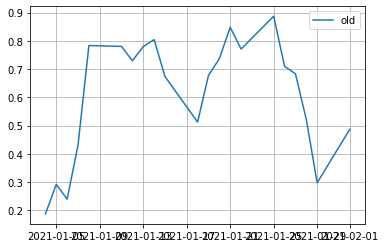

[7.937523936132048e-10,
 8.538835935294327e-10,
 0.06741745873815132,
 7.681893915524239e-10,
 0.6378033587962748,
 0.2947791800497485]

In [149]:
#trad_sharpe(dataframe,rf,upperbound,var_mod,start_train,end_train,start_test,end_test)
trad_sharpe(port_ret_train, 0,port_ret_test,df_var_garch,'2016-01-01','2020-12-31','2021-01-01','2021-02-01')

Period 2

     pcost       dcost       gap    pres   dres
 0:  3.1958e+02 -5.8313e+05  6e+05  2e+01  2e+03
 1:  3.6726e+02 -3.3759e+05  5e+05  1e+01  1e+03
 2:  3.2297e+02 -2.2597e+05  4e+05  1e+01  1e+03
 3:  3.7181e+02 -4.6049e+04  6e+04  1e+00  1e+02
 4:  4.3996e+02 -6.4327e+03  7e+03  8e-02  8e+00
 5:  4.3099e+02  2.1711e+02  2e+02  1e-03  2e-01
 6:  3.6185e+02  3.3863e+02  2e+01  2e-05  2e-03
 7:  3.4423e+02  3.4363e+02  6e-01  4e-08  4e-06
 8:  3.4389e+02  3.4386e+02  3e-02  1e-09  1e-07
 9:  3.4388e+02  3.4388e+02  7e-04  1e-11  1e-09
10:  3.4388e+02  3.4388e+02  7e-06  5e-13  1e-11
Optimal solution found.
dd, 4.998064574465389e-06
sharpe, 2.1858934333269087


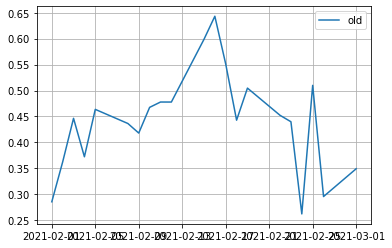

[0.043022531873867884,
 3.566864196306391e-09,
 0.3083922834811119,
 0.0025270898427121394,
 0.6460580890702287,
 2.1652151129537363e-09]

In [150]:
trad_sharpe(port_ret_train, 0,port_ret_test,df_var_ann,'2016-02-01','2021-01-01','2021-02-01','2021-03-01')

     pcost       dcost       gap    pres   dres
 0:  3.1958e+02 -5.8153e+05  6e+05  2e+01  2e+03
 1:  3.6319e+02 -3.3568e+05  5e+05  2e+01  1e+03
 2:  3.1916e+02 -1.9267e+05  5e+05  2e+01  1e+03
 3:  3.8703e+02 -4.7130e+04  1e+05  3e+00  3e+02
 4:  5.2247e+02 -8.7679e+04  9e+04  2e+00  1e+02
 5:  5.5046e+02 -7.6828e+03  8e+03  2e-01  1e+01
 6:  5.5174e+02  3.1849e+02  2e+02  3e-03  2e-01
 7:  4.7995e+02  4.5489e+02  3e+01  6e-05  5e-03
 8:  4.6220e+02  4.6187e+02  3e-01  6e-08  4e-06
 9:  4.6202e+02  4.6201e+02  3e-03  6e-10  4e-08
10:  4.6202e+02  4.6202e+02  3e-05  5e-12  4e-10
Optimal solution found.
dd, 4.758517551090335e-06
sharpe, 1.6891790465866408


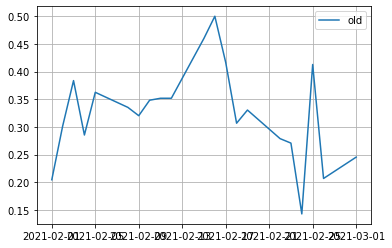

[6.961842511646979e-09,
 2.4932135489162828e-09,
 0.11476501252077119,
 3.201252569136393e-09,
 0.6292681222550213,
 0.2559668525678989]

In [151]:
trad_sharpe(port_ret_train, 0,port_ret_test,df_var_garch,'2016-02-01','2021-01-01','2021-02-01','2021-03-01')

Period 3

     pcost       dcost       gap    pres   dres
 0:  2.6985e+02 -6.5389e+05  7e+05  2e+01  2e+03
 1:  3.1989e+02 -1.9464e+05  3e+05  9e+00  1e+03
 2:  3.6280e+02 -7.8939e+04  1e+05  3e+00  3e+02
 3:  3.9964e+02 -1.7986e+04  2e+04  4e-01  5e+01
 4:  4.1976e+02  4.4279e+01  4e+02  4e-03  4e-01
 5:  3.7505e+02  3.3185e+02  4e+01  2e-04  2e-02
 6:  3.5321e+02  3.4780e+02  5e+00  2e-05  2e-03
 7:  3.5155e+02  3.5035e+02  1e+00  4e-06  4e-04
 8:  3.5104e+02  3.5019e+02  8e-01  1e-08  1e-06
 9:  3.5085e+02  3.5076e+02  9e-02  4e-10  5e-08
10:  3.5083e+02  3.5083e+02  3e-03  5e-13  3e-15
11:  3.5083e+02  3.5083e+02  3e-05  1e-13  2e-14
Optimal solution found.
dd, 2.3584959304571384e-06
sharpe, 0.6099623656682278


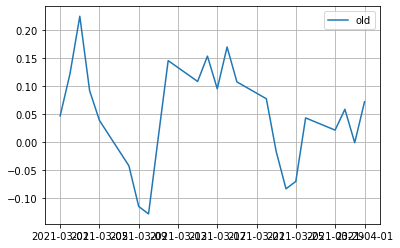

[0.03336950836796859,
 2.8353440615665892e-09,
 0.27182431833389914,
 0.005806474419229305,
 0.6889996929323102,
 3.1112486046696926e-09]

In [152]:
trad_sharpe(port_ret_train, 0,port_ret_test,df_var_ann,'2016-03-01','2021-02-01','2021-03-01','2021-04-01')

     pcost       dcost       gap    pres   dres
 0:  2.6985e+02 -6.5245e+05  7e+05  2e+01  2e+03
 1:  3.1024e+02 -2.2031e+05  4e+05  1e+01  1e+03
 2:  3.6415e+02 -1.7556e+05  3e+05  7e+00  6e+02
 3:  4.0991e+02 -5.9265e+04  1e+05  3e+00  3e+02
 4:  5.6733e+02 -2.9605e+04  3e+04  3e-01  3e+01
 5:  5.6589e+02 -2.6119e+01  6e+02  5e-03  4e-01
 6:  4.6268e+02  3.9111e+02  7e+01  2e-04  2e-02
 7:  4.4876e+02  4.4096e+02  8e+00  6e-06  5e-04
 8:  4.4409e+02  4.4396e+02  1e-01  7e-08  6e-06
 9:  4.4403e+02  4.4403e+02  1e-03  7e-10  6e-08
10:  4.4403e+02  4.4403e+02  1e-05  7e-12  6e-10
Optimal solution found.
dd, 2.2977396025453345e-06
sharpe, 3.004590733428114


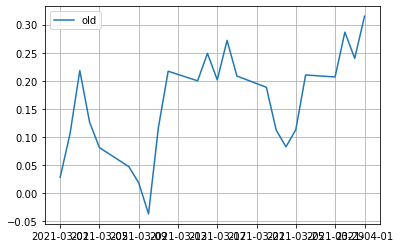

[1.5376157153249147e-10,
 8.538632590346207e-10,
 0.07050862625219957,
 3.2644305170809647e-09,
 0.7236074232871805,
 0.20588394618856454]

In [153]:
trad_sharpe(port_ret_train, 0,port_ret_test,df_var_garch,'2016-03-01','2021-02-01','2021-03-01','2021-04-01')

In [ ]:
# Period all

     pcost       dcost       gap    pres   dres
 0:  4.2963e+02 -6.3983e+05  7e+05  2e+01  2e+03
 1:  4.6082e+02 -5.4225e+05  6e+05  2e+01  2e+03
 2:  4.2597e+02 -4.5892e+05  6e+05  2e+01  2e+03
 3:  4.4776e+02 -1.8856e+05  2e+05  5e+00  6e+02
 4:  4.3051e+02 -3.3579e+04  5e+04  1e+00  1e+02
 5:  4.7574e+02 -2.0176e+03  2e+03  1e-02  1e+00
 6:  4.3802e+02  2.7190e+02  2e+02  5e-04  6e-02
 7:  3.9588e+02  3.7560e+02  2e+01  5e-13  2e-16
 8:  3.9118e+02  3.8430e+02  7e+00  2e-13  9e-17
 9:  3.8736e+02  3.8651e+02  8e-01  2e-13  9e-17
10:  3.8704e+02  3.8703e+02  9e-03  5e-13  1e-16
11:  3.8703e+02  3.8703e+02  9e-05  5e-13  8e-17
Optimal solution found.
dd, 5.798566051089438e-06
sharpe, 0.5187390291594937


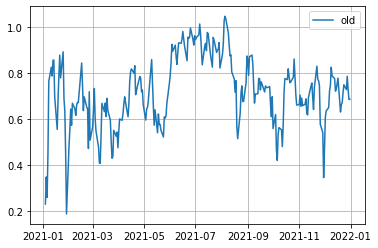

[2.657684425482043e-08,
 2.3416899010859096e-08,
 0.3461886154393867,
 0.015209694889832811,
 0.6386016079575557,
 3.1719481507250874e-08]

In [161]:
trad_sharpe(port_ret_train, 0,port_ret_test,df_var_ann,'2016-01-01','2020-12-31','2021-01-01','2021-12-31')

     pcost       dcost       gap    pres   dres
 0:  4.2963e+02 -6.3789e+05  7e+05  3e+01  2e+03
 1:  4.6031e+02 -5.4867e+05  6e+05  2e+01  2e+03
 2:  4.2412e+02 -4.6093e+05  6e+05  2e+01  2e+03
 3:  4.4632e+02 -2.3447e+05  3e+05  9e+00  8e+02
 4:  4.3283e+02 -1.5181e+04  2e+05  5e+00  5e+02
 5:  5.4389e+02 -9.6407e+03  2e+05  3e+00  3e+02
 6:  9.1129e+02 -2.9164e+04  3e+04  3e-01  2e+01
 7:  8.8532e+02 -1.2818e+01  9e+02  4e-03  3e-01
 8:  6.6731e+02  4.6394e+02  2e+02  8e-04  7e-02
 9:  6.6287e+02  6.4598e+02  2e+01  2e-05  2e-03
10:  6.5186e+02  6.5160e+02  3e-01  2e-07  2e-05
11:  6.5172e+02  6.5172e+02  3e-03  2e-09  2e-07
12:  6.5172e+02  6.5172e+02  3e-05  2e-11  2e-09
Optimal solution found.
dd, 5.889788805689022e-06
sharpe, 0.5315553643537296


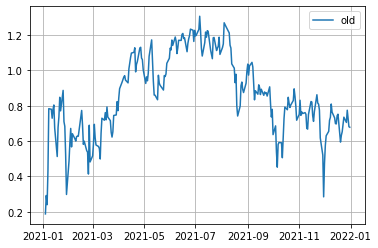

[7.937523936132048e-10,
 8.538835935294327e-10,
 0.06741745873815132,
 7.681893915524239e-10,
 0.6378033587962748,
 0.2947791800497485]

In [162]:
trad_sharpe(port_ret_train, 0,port_ret_test,df_var_garch,'2016-01-01','2020-12-31','2021-01-01','2021-12-31')